KMeans groups data points into K clusters such that point in the same cluster are as 
-Who is supposed to give K value -- model or business owner
-K--> No.of s=clusters
-Means --- Avg

real time projects on kmeans
1. customer segmentation for ecommerce website
2. movie recommendation  cluster
3. smart phone usage segementation (data users, call users,low users)
4. patient risk segmentation 
bp, parameters : high risk , medium, low risk
product grouping segmentation : premiun
fraud detection (normal behaviour,suspicious)
student performance (toppers,avg student,risk students)


In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv.xls")

In [38]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [39]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [44]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [43]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

<Axes: >

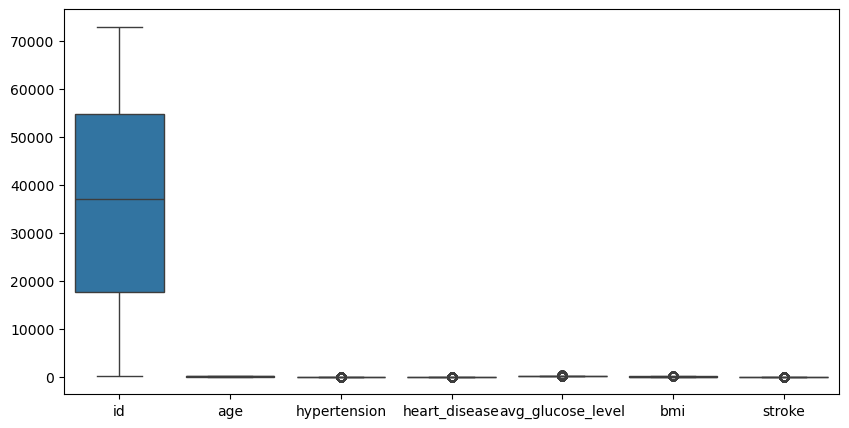

In [42]:
# boxplot for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df)

In [45]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

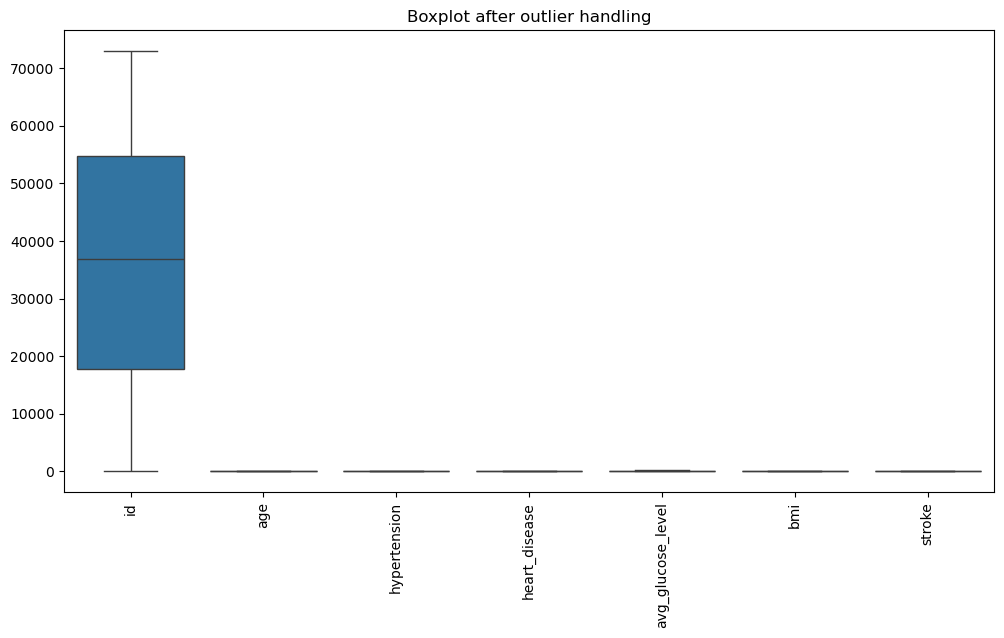

In [46]:
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)

# verify outliers are handled
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot after outlier handling")
plt.show()

In [47]:
X = df[['age',
        'hypertension',
        'heart_disease',
        'avg_glucose_level',
        'bmi']]

In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [49]:
K = 3

In [50]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [51]:
df['Cluster'] = clusters

In [53]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(centers,
                               columns=X.columns)

print(cluster_centers)

         age  hypertension  heart_disease  avg_glucose_level        bmi
0  18.973134           0.0            0.0          91.967454  22.606866
1  53.937647           0.0            0.0          85.948698  31.441647
2  58.267797           0.0            0.0         161.441737  32.277175


In [54]:
risk_map = {
    0:'Low Risk',
    1:'Medium Risk',
    2:'High Risk'
}

df['Risk_Level'] = df['Cluster'].map(risk_map)

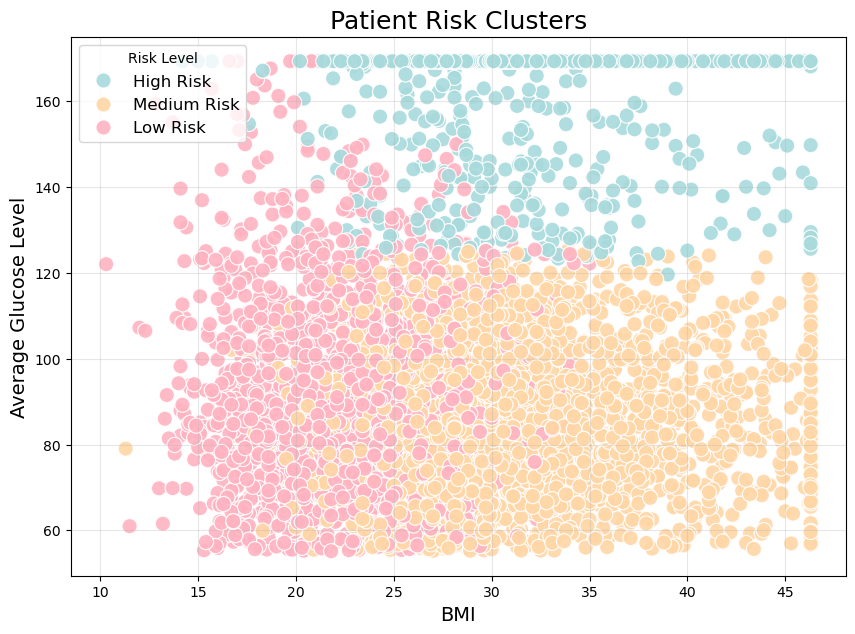

In [59]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df['bmi'],
    y=df['avg_glucose_level'],
    hue=df['Risk_Level'],
    palette=['#A8DADC', '#FFD6A5', '#FFB3C1'],
    s=120,
    alpha=0.9
)

plt.title("Patient Risk Clusters", fontsize=18)

plt.xlabel("BMI", fontsize=14)

plt.ylabel("Average Glucose Level", fontsize=14)

plt.legend(title='Risk Level', fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()